In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df = df[['Age','BMI','Glucose','Insulin','BloodPressure','Pregnancies','Outcome']]

In [7]:
df.head()

,Age,BMI,Glucose,Insulin,BloodPressure,Pregnancies,Outcome
0,50,33.6,148,0,72,6,1
1,31,26.6,85,0,66,1,0
2,32,23.3,183,0,64,8,1
3,21,28.1,89,94,66,1,0
4,33,43.1,137,168,40,0,1


In [8]:
df.sample(10)

,Age,BMI,Glucose,Insulin,BloodPressure,Pregnancies,Outcome
315,26,34.1,112,94,68,2,0
657,41,38.9,120,200,80,1,0
399,25,34.9,193,0,70,3,1
552,66,27.8,114,0,88,6,0
558,42,46.2,103,0,68,11,0
182,21,27.7,0,23,74,1,0
240,21,29.2,91,0,64,1,0
75,22,24.7,0,0,48,1,0
229,24,45.2,117,53,80,0,0
386,35,32.3,116,0,74,5,1


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,768.0,33.240885,11.760232,21.0,24.0,29.0,41.00,81.0
BMI,768.0,31.992578,7.884160,0.0,27.3,32.0,36.60,67.1
Glucose,768.0,120.894531,31.972618,0.0,99.0,117.0,140.25,199.0
Insulin,768.0,79.799479,115.244002,0.0,0.0,30.5,127.25,846.0
BloodPressure,768.0,69.105469,19.355807,0.0,62.0,72.0,80.00,122.0
Pregnancies,768.0,3.845052,3.369578,0.0,1.0,3.0,6.00,17.0
Outcome,768.0,0.348958,0.476951,0.0,0.0,0.0,1.00,1.0


### Data cleaning

We can see some zero min values of some columns 
zero value of columns like bmi,glucose e.t.c doesnt make any sense. Thus it indicate missing values

It is better to replace zeros with nan since after that counting them would be easier and zeros need to be replaced with suitable values

In [10]:
df_copy = df.copy(deep=True)

In [11]:
df_copy = df.copy(deep = True)
df_copy[['BMI','Glucose','Insulin','BloodPressure']] = df_copy[['BMI','Glucose','Insulin','BloodPressure']].replace(0,np.NaN)
print(df_copy.isnull().sum())


Age                0
BMI               11
Glucose            5
Insulin          374
BloodPressure     35
Pregnancies        0
Outcome            0
dtype: int64


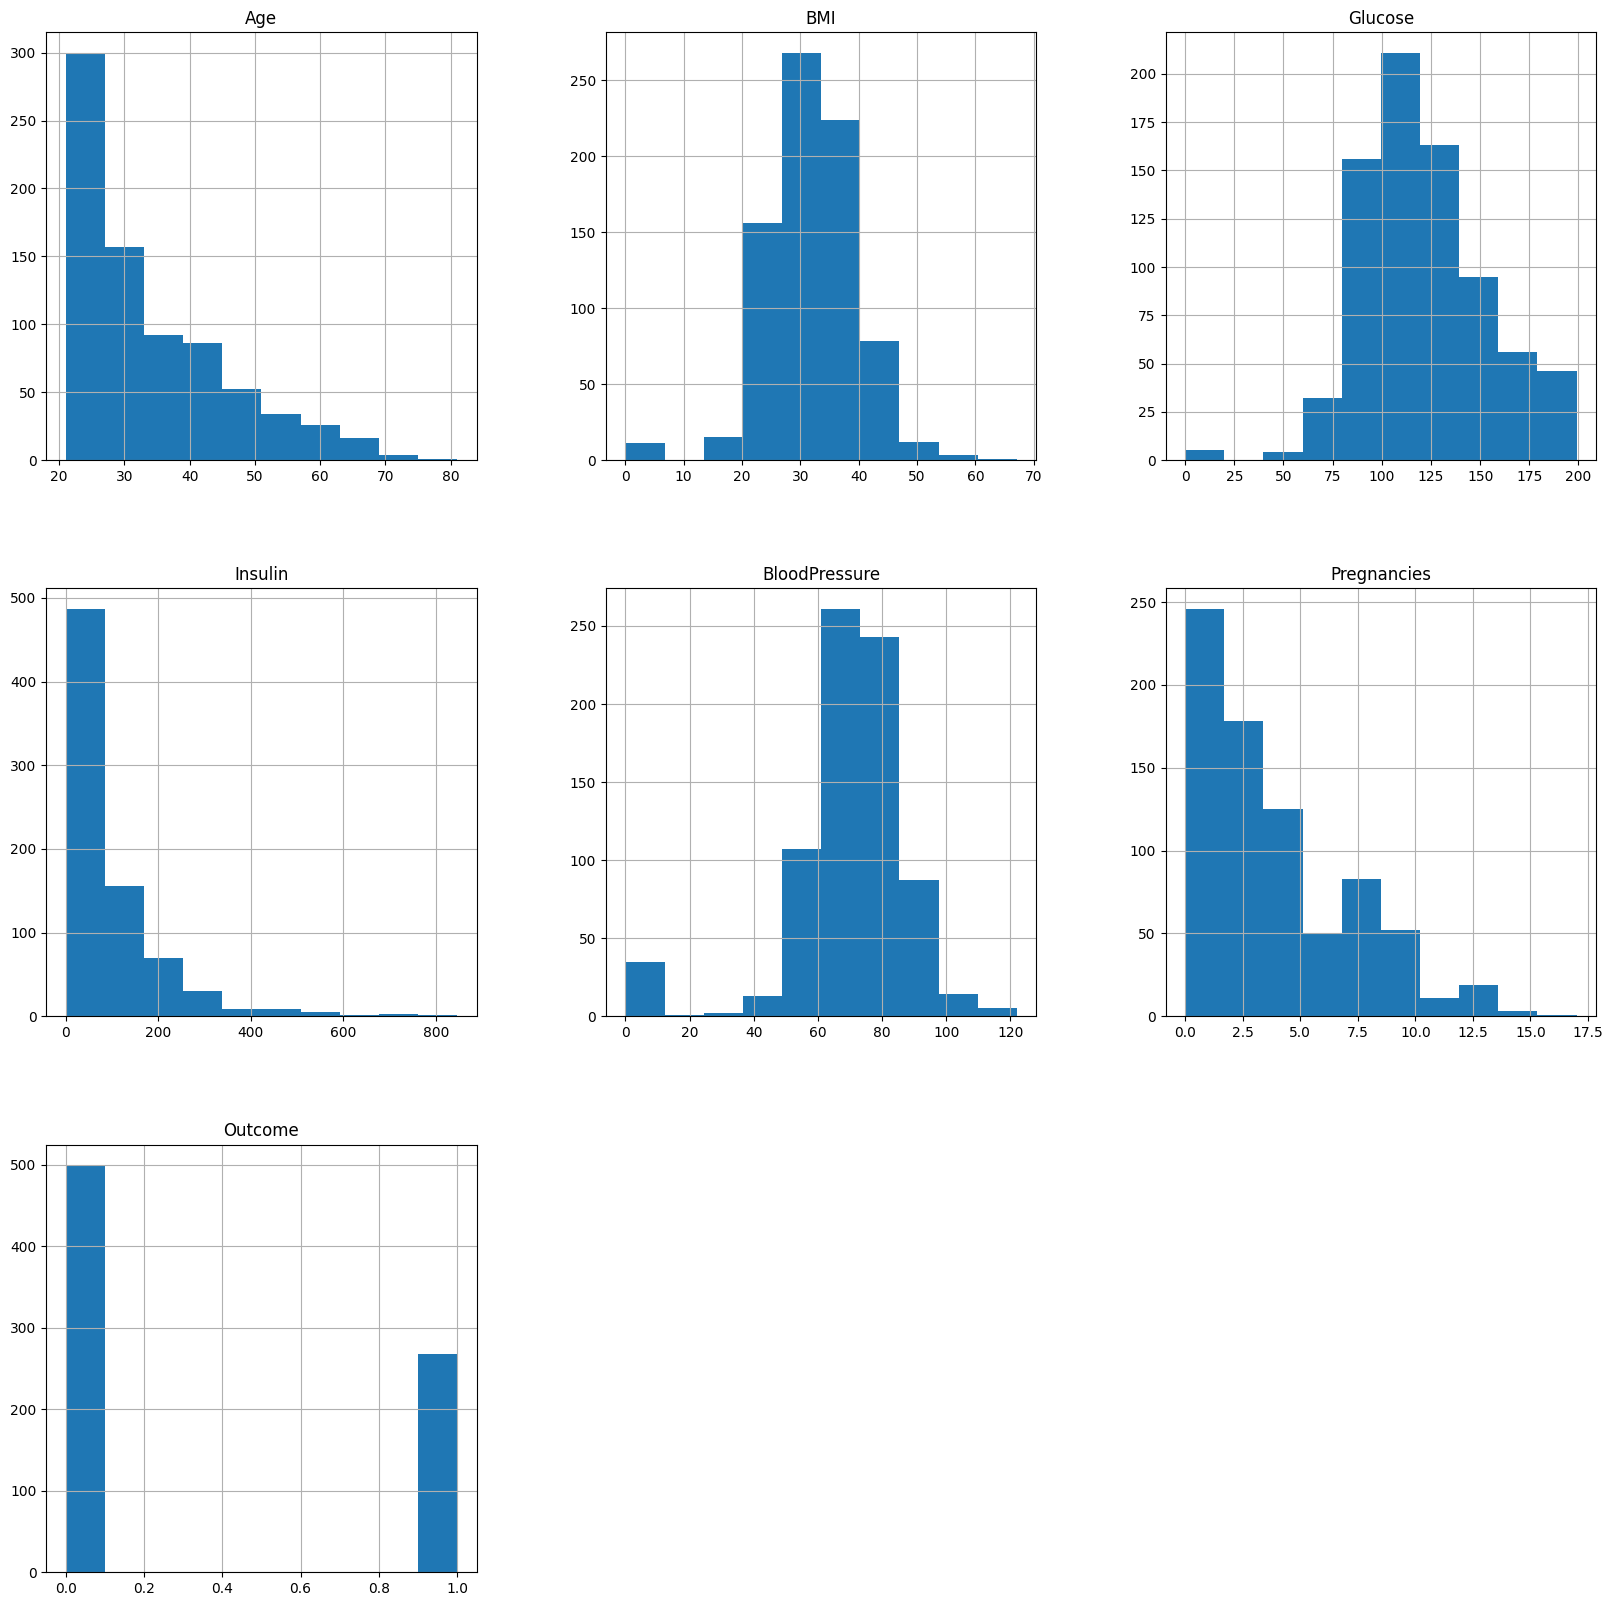

In [10]:
p = df.hist(figsize = (20,20))

In [12]:
df_copy['Glucose'] = df_copy['Glucose'].fillna(df_copy['Glucose'].mean())
df_copy['BloodPressure'] = df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean())
df_copy['Insulin'] = df_copy['Insulin'].fillna(df_copy['Insulin'].median())
df_copy['BMI'] = df_copy['BMI'].fillna(df_copy['BMI'].median())


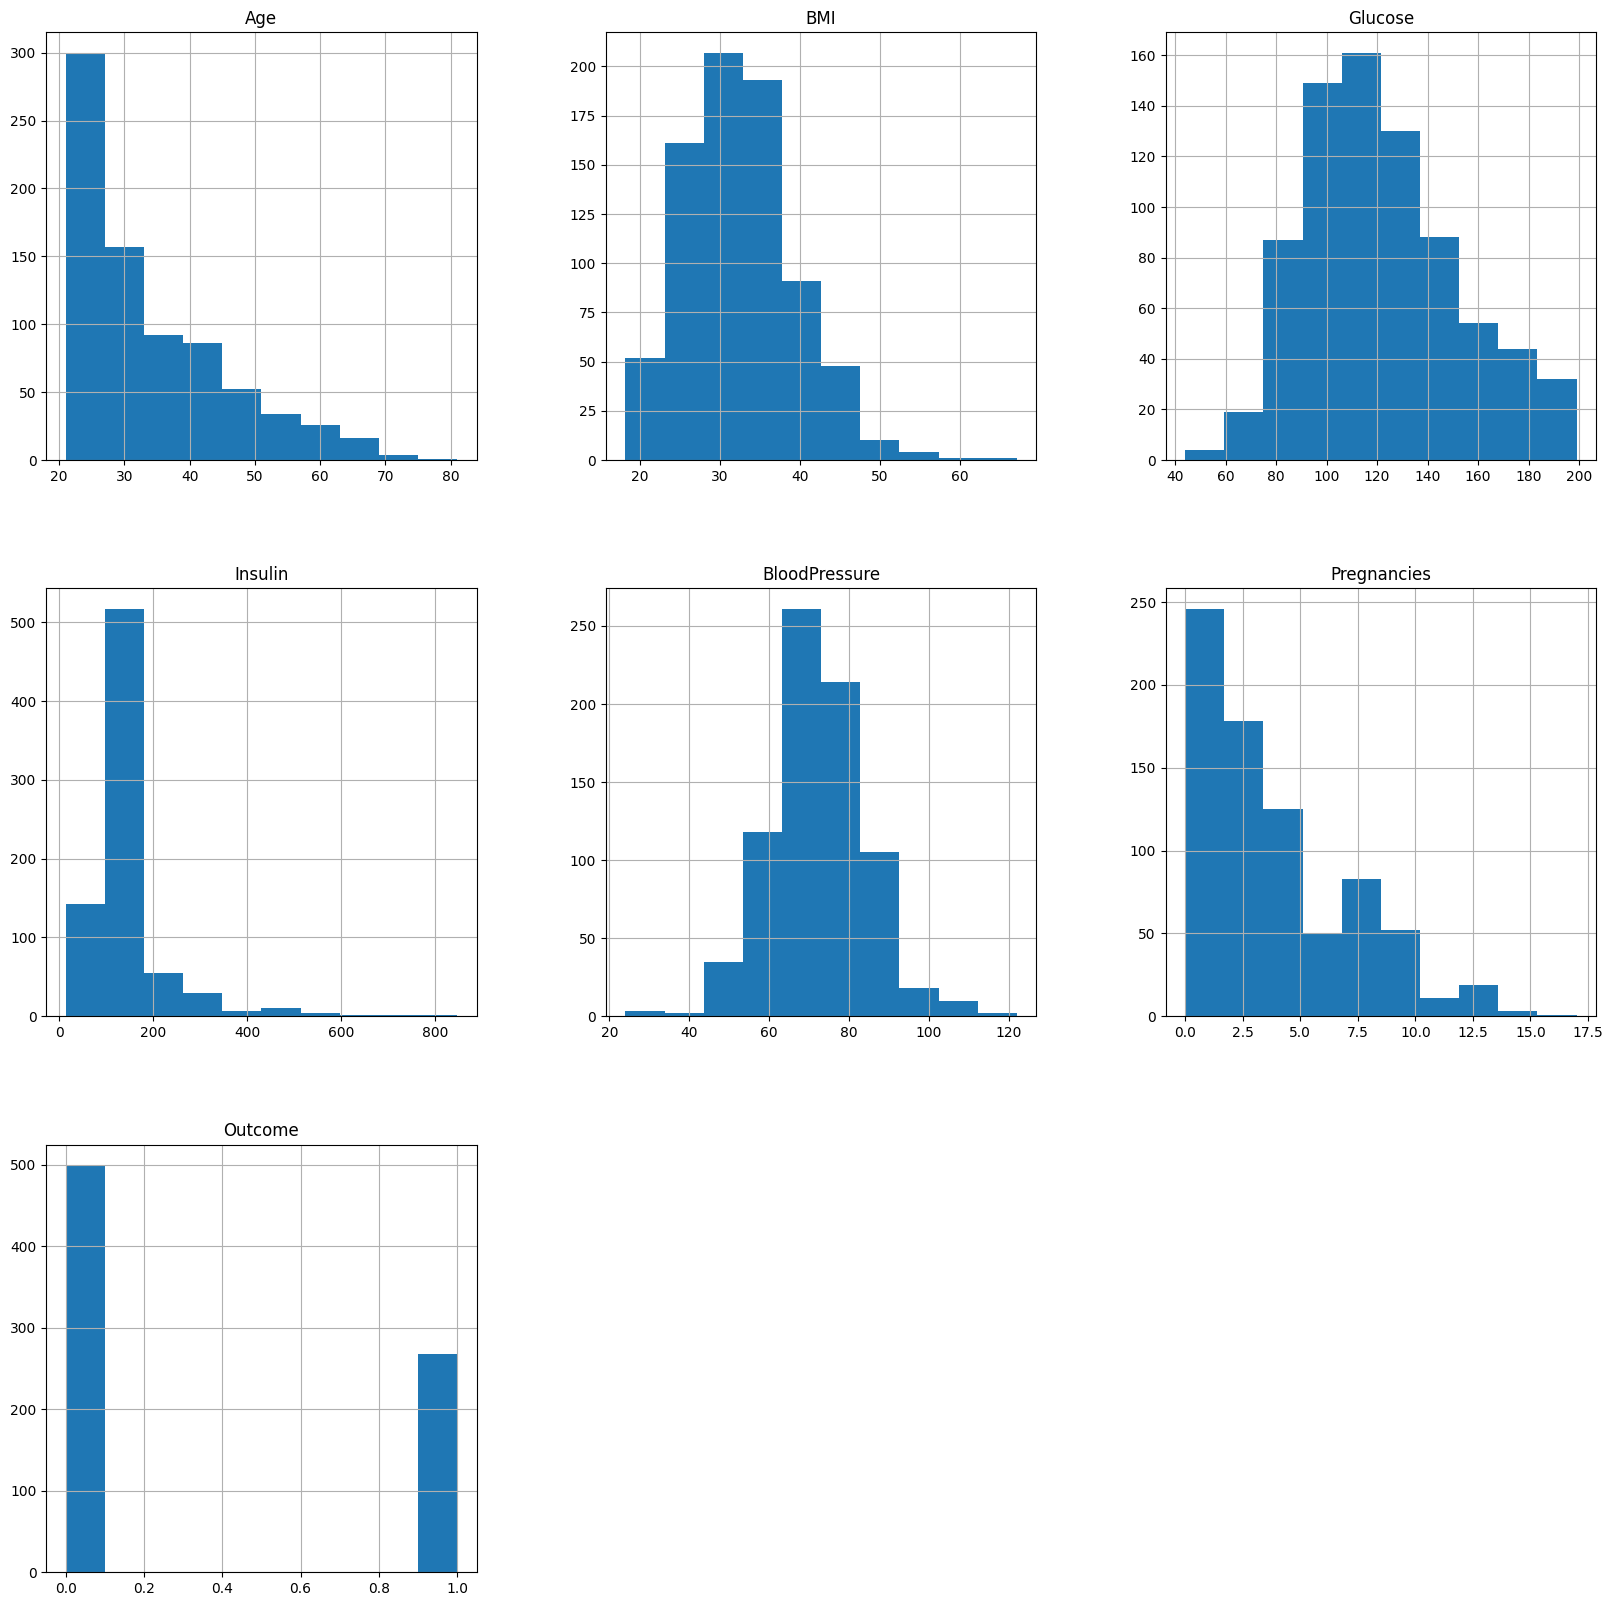

In [13]:
p = df_copy.hist(figsize = (20,20))

In [14]:
df.shape

(768, 7)

In [15]:
print(df_copy.isnull().sum())

Age              0
BMI              0
Glucose          0
Insulin          0
BloodPressure    0
Pregnancies      0
Outcome          0
dtype: int64


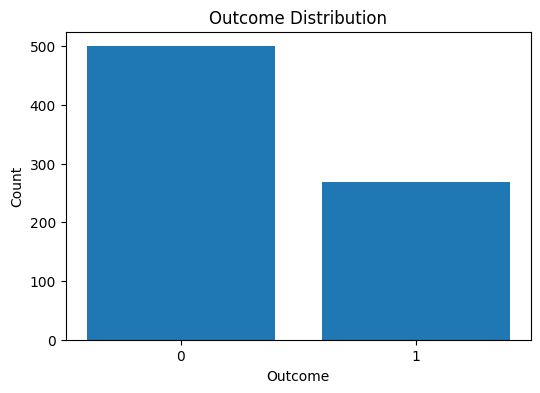

In [17]:
counts = df_copy['Outcome'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.xticks(counts.index)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Outcome Distribution')
plt.show()

The above graph shows that the data is biased towards datapoints having outcome value as 0 where it means that diabetes was not present actually. The number of non-diabetics is almost twice the number of diabetic patients

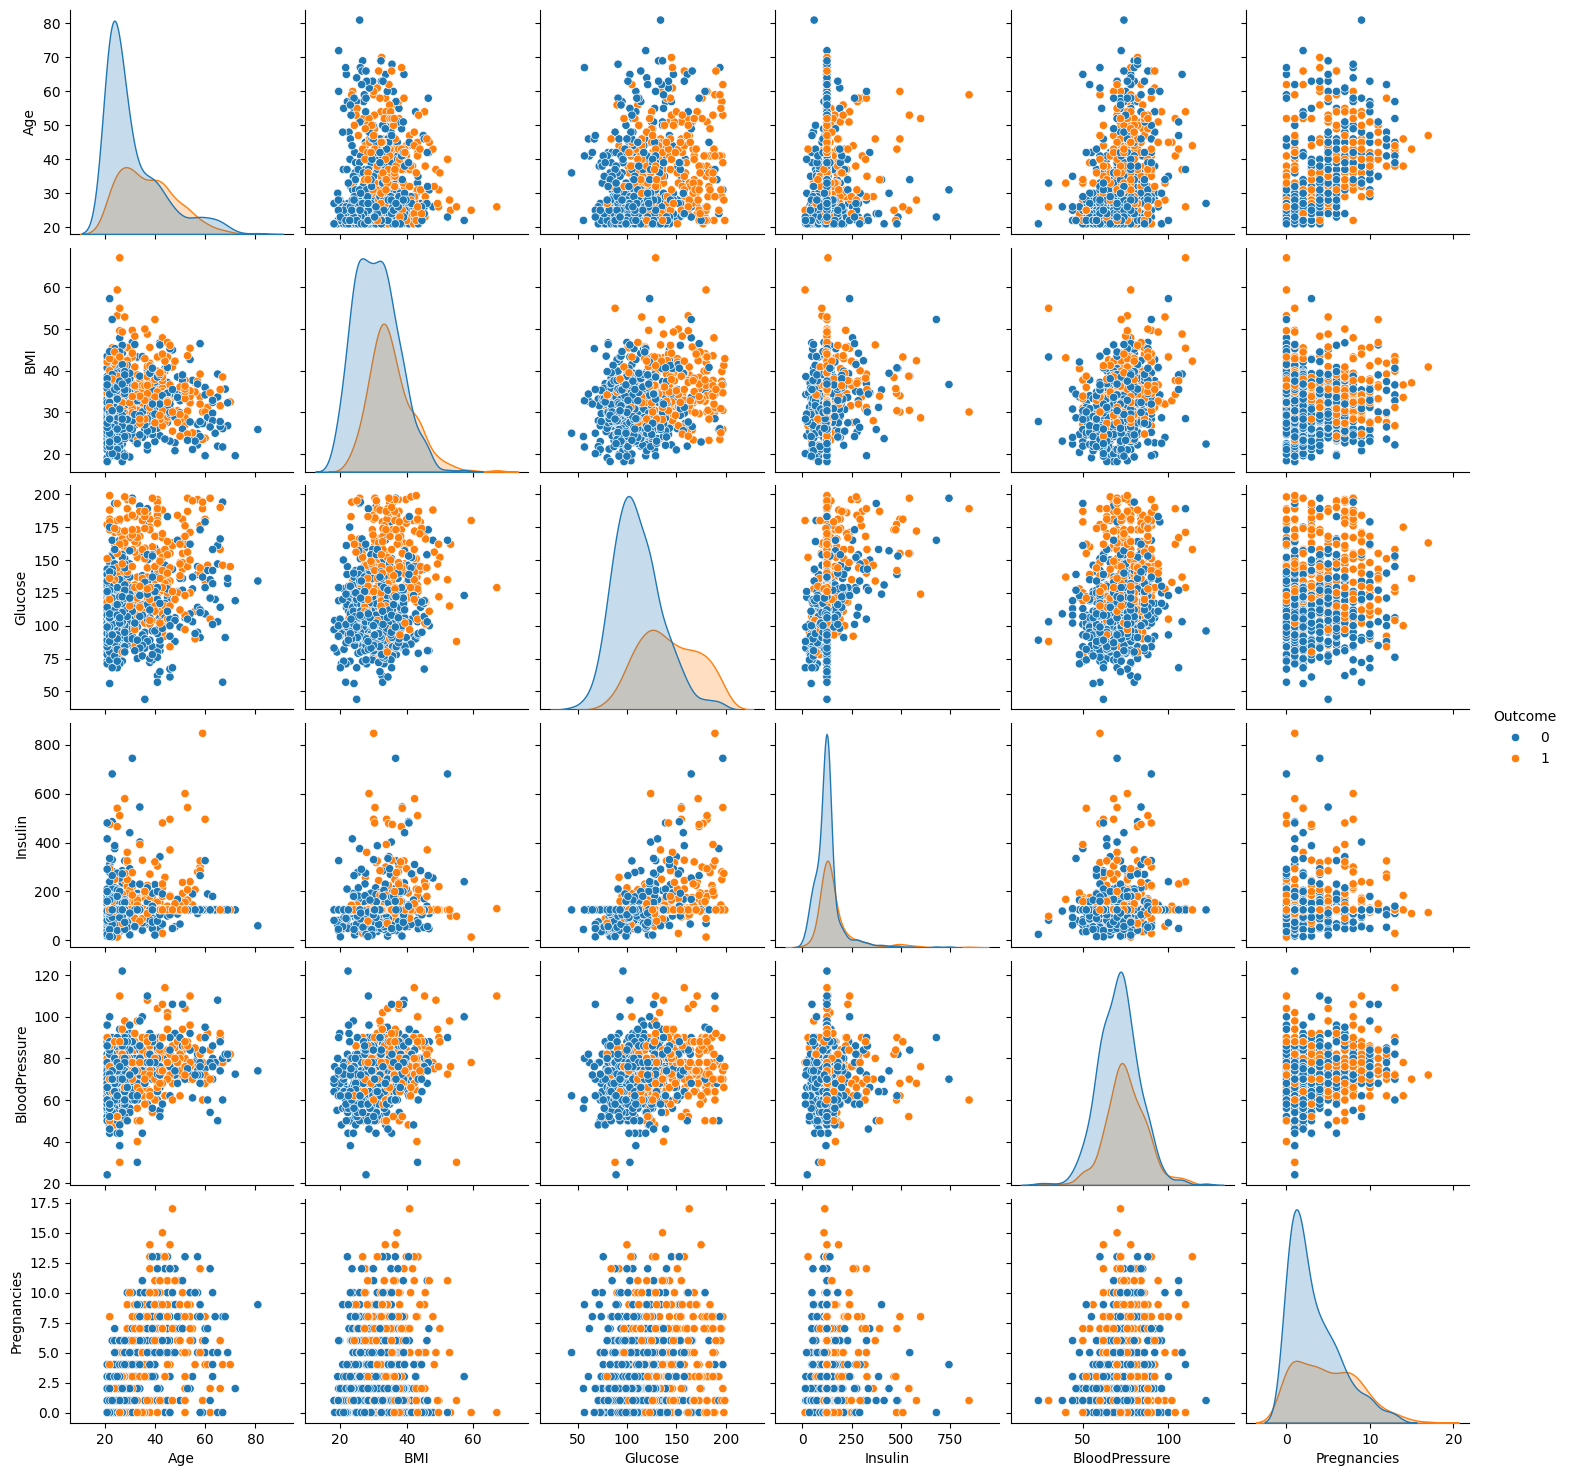

In [18]:
import seaborn as sns
p=sns.pairplot(df_copy, hue = 'Outcome')

<Axes: >

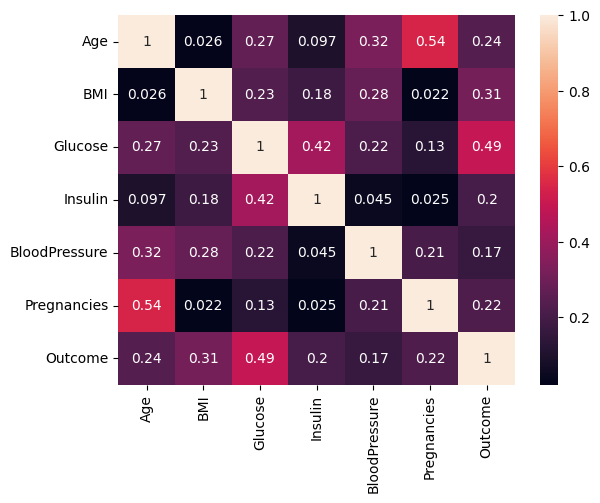

In [19]:
sns.heatmap(df_copy.corr(),annot=True)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = df_copy.drop("Outcome", axis=1)

X = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)


In [21]:
X.head()

,Age,BMI,Glucose,Insulin,BloodPressure,Pregnancies
0,1.425995,0.166619,0.865108,-0.181541,-0.033518,0.639947
1,-0.190672,-0.852200,-1.206162,-0.181541,-0.529859,-0.844885
2,-0.105584,-1.332500,2.015813,-0.181541,-0.695306,1.233880
3,-1.041549,-0.633881,-1.074652,-0.540642,-0.529859,-0.844885
4,-0.020496,1.549303,0.503458,0.316566,-2.680669,-1.141852


In [22]:
y = df_copy.Outcome

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=42, stratify=y)

In [24]:
X_train

,Age,BMI,Glucose,Insulin,BloodPressure,Pregnancies
657,0.660206,0.938011,-0.055456,0.687250,0.628269,-0.844885
462,0.490030,0.414047,-1.567812,-1.061917,-0.198965,1.233880
171,-0.360847,0.428601,0.404826,-0.123622,-0.198965,0.639947
210,-0.701198,-0.692100,-1.337671,-0.181541,-1.026200,-0.547919
147,0.064591,-0.284572,-0.515738,-0.251045,-0.695306,-0.547919
...,...,...,...,...,...,...
113,-0.701198,0.224838,-1.502057,-0.181541,-0.860753,0.046014
556,-0.275760,0.821575,-0.811634,-0.181541,-0.198965,-0.844885
254,0.915469,-0.706654,-0.976020,1.359116,-0.860753,2.421746
647,-0.956462,0.777911,1.884304,0.212311,-1.853434,-1.141852


In [25]:
y_train

657    0
462    0
171    1
210    0
147    0
      ..
113    0
556    0
254    1
647    1
107    0
Name: Outcome, Length: 512, dtype: int64

In [26]:
from sklearn.neighbors import KNeighborsClassifier


test_scores = []
train_scores = []

for i in range(1,15):

    knn = KNeighborsClassifier(i)
    knn.fit(X_train,y_train)
    
    train_scores.append(knn.score(X_train,y_train))
    test_scores.append(knn.score(X_test,y_test))

In [27]:
max_train_score = max(train_scores)
train_scores_ind = [i for i, v in enumerate(train_scores) if v == max_train_score]
print('Max train score {} % and k = {}'.format(max_train_score*100,list(map(lambda x: x+1, train_scores_ind))))


Max train score 100.0 % and k = [1]


## Result Visualization

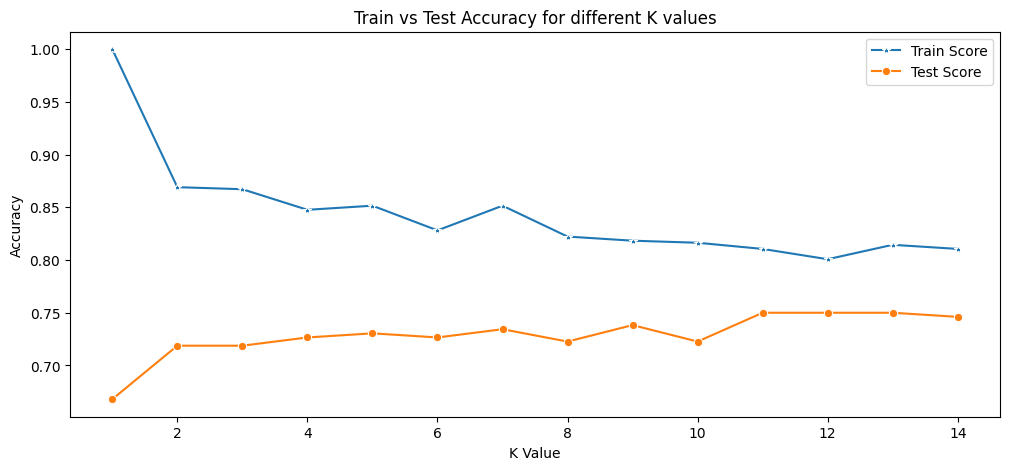

In [28]:
plt.figure(figsize=(12,5))

sns.lineplot(x=range(1,15), y=train_scores, marker='*', label='Train Score')
sns.lineplot(x=range(1,15), y=test_scores, marker='o', label='Test Score')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy for different K values")
plt.legend()
plt.show()


The best result is captured at k = 11 hence 11 is used for the final model

In [29]:
#Setup a knn classifier with k neighbors
knn = KNeighborsClassifier(11)

knn.fit(X_train,y_train)
knn.score(X_test,y_test)

0.75

In [30]:
y_pred = knn.predict(X_test)
print(y_pred)  


[0 1 1 0 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1
 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 1 0 0 0 0 1 0
 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1
 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1 1 1 0 0 1
 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0]


In [31]:
print(y_test)

52     0
64     1
630    1
707    0
330    0
      ..
33     0
596    0
88     1
679    0
112    0
Name: Outcome, Length: 256, dtype: int64


In [32]:
from sklearn.metrics import roc_curve
y_pred_proba = knn.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

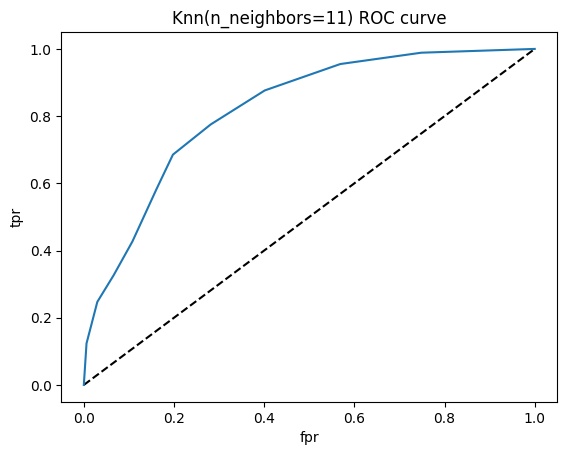

In [33]:
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='Knn')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('Knn(n_neighbors=11) ROC curve')
plt.show()

In [34]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred_proba)

0.8192827827491085

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
33
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=11))
])

knn_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [62]:
knn_pipeline.score(X_test, y_test)


0.7421875

In [74]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    knn, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

importance = result.importances_mean
feature_names = X.columns

import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)


         Feature  Importance
2        Glucose    0.108203
1            BMI    0.029687
3        Insulin    0.026562
5    Pregnancies    0.023047
4  BloodPressure    0.014844
0            Age    0.013281
